In [1]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy import integrate
from scipy.ndimage import gaussian_filter1d

from JupyterNotebooks_et_al.LTPY_fit_comparisoin_from_outside import avgY1

from JupyterNotebooks_et_al.LTPY_fit_comparisoin import smoothed_mine

LENSFOCAL = 502.5 # this is in mm
ZERO_X = 5280/2
ZERO_Y = 4600 /2
PIXEL = 2.74 # size of pixels in microns

In [40]:
def get_data_out(ltp_data):
    return (ltp_data[:,2], #AVG X carriage position
            ltp_data[:,11], #AVG Y centroid.
            ltp_data[:,12], #FWD RAW slope
            ltp_data[:,13] #BWD RAW slope
            )
def slope_calc(value, focal):
    slope_error = 0.5 * (math.atan((2.74 * (ZERO_X - value))/(focal* 1000))) # this is in microns, so in µrad?
    return(slope_error)
def my_fit (arrayX, arrayY, order):
    coeff = np.polyfit(arrayX, arrayY, order)
    p = np.poly1d(coeff)
    fit = p(arrayX)
    radius = 1 /coeff[0]
    return(fit, radius)
def RMS(array):
    RMS = np.sqrt(np.mean(np.square(array)))
    return(RMS)

def figure_error(arrayX, arrayY):
    """
    Calculates the figure error given and array of positions/slopes
    :param arrayX: y-position of the centroid? or X-position of the head?
    :param arrayY: slopes
    :return: an array, heights.
    """

    heights = []
    heights = integrate.cumtrapz(arrayY, arrayX, initial=0)
    return (heights)
def gaussian_filter(myslope,
                    beam_step = None,
                    beam_waist = None):
    if beam_step == None:
        beam_step = 1 # this is in mm
    if beam_waist == None:
        beam_waist = 1.5 # FHWM I know in px time px size
    sigma_points = (beam_waist /2.355 )/beam_step
    smoothed_slope = gaussian_filter1d(myslope,
                                       sigma = sigma_points,
                                       mode='reflect')
    return(smoothed_slope)


In [52]:
ltp_data1 = np.loadtxt("FullData16-06_20260910.txt", skiprows = 12)
ltp_data2 = np.loadtxt("FullData16-13_20260910.txt", skiprows=12)
ltp_data3 = np.loadtxt("FullData16-21_20260910.txt", skiprows=12)
ltp_data4 = np.loadtxt("FullData16-28_20260910.txt", skiprows=12)

In [53]:
myXpos1, myavgYcentroid1, myFWD_raw_slope1, myBWD_raw_slope1 = get_data_out(ltp_data1)
myXpos2, myavgYcentroid2, myFWD_raw_slope2, myBWD_raw_slope2 = get_data_out(ltp_data2)
myXpos3, myavgYcentroid3, myFWD_raw_slope3, myBWD_raw_slope3 = get_data_out(ltp_data3)
myXpos4, myavgYcentroid4, myFWD_raw_slope4, myBWD_raw_slope4 = get_data_out(ltp_data4)

RMS slope from averaging slopes: 1.6041422682474749 urad
RMS slope from smoothed averaging slopes: 1.4810107756990218 urad


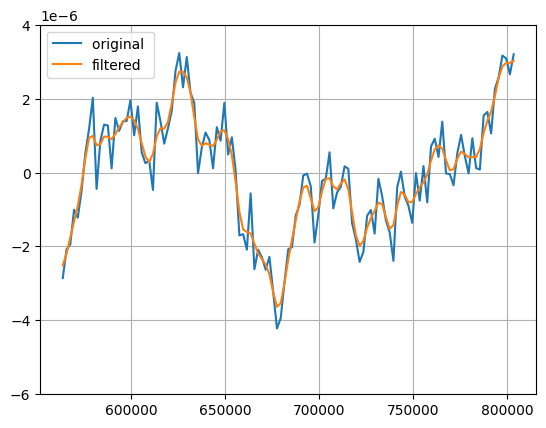

In [56]:
avg_raw_slope1 = (myBWD_raw_slope1+myFWD_raw_slope2+myFWD_raw_slope3+myFWD_raw_slope4)/4
fit_avg, radius_avg = my_fit(myXpos1, avg_raw_slope1, 1)

detrended_avg1 = avg_raw_slope1 - fit_avg

smoothed_avg1 = gaussian_filter(detrended_avg1, beam_waist = 2.7)

rms_avg = RMS(detrended_avg1)
rms_smooted_avg = RMS(smoothed_avg1)
print(f"RMS slope from averaging slopes: {1000000*rms_avg} urad")
print(f"RMS slope from smoothed averaging slopes: {1000000*rms_smooted_avg} urad")

plt.figure()
plt.plot(myXpos1, detrended_avg1, label = "original ")
plt.plot(myXpos1, smoothed_avg1, label = "filtered")
plt.ylim(-6e-6, 4e-6)
plt.grid()
plt.legend()
plt.show()

RMS slope from averaging slopes: 1.142887411663391 urad
RMS slope from smoothed averaging slopes: 0.9662657825317233 urad


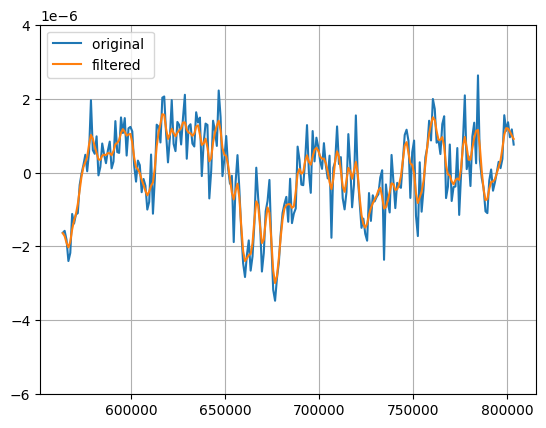

In [51]:
avg_raw_slope = (myFWD_raw_slope+myBWD_raw_slope)/2
fit_avg, radius_avg = my_fit(myXpos, avg_raw_slope, 1)

detrended_avg = avg_raw_slope - fit_avg

smoothed_avg = gaussian_filter(detrended_avg, beam_waist = 2.7)

rms_avg = RMS(detrended_avg)
rms_smooted_avg = RMS(smoothed_avg)
print(f"RMS slope from averaging slopes: {1000000*rms_avg} urad")
print(f"RMS slope from smoothed averaging slopes: {1000000*rms_smooted_avg} urad")

plt.figure()
plt.plot(myXpos, detrended_avg, label = "original ")
plt.plot(myXpos, smoothed_avg, label = "filtered")
plt.ylim(-6e-6, 4e-6)
plt.grid()
plt.legend()
plt.show()

.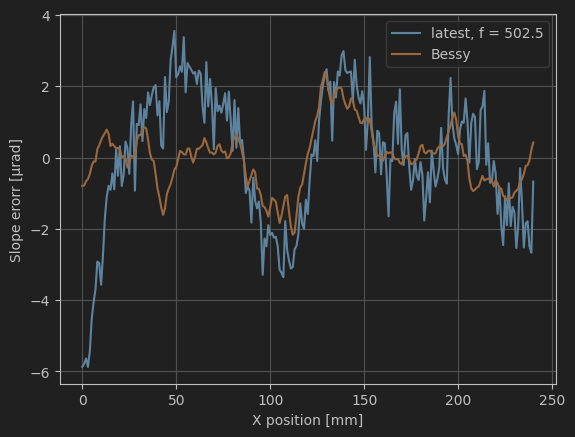

Original Fit RMS: 1.4356814798196202 urad
Gaussian smoothed RMS : 1.4356814798196202 urad


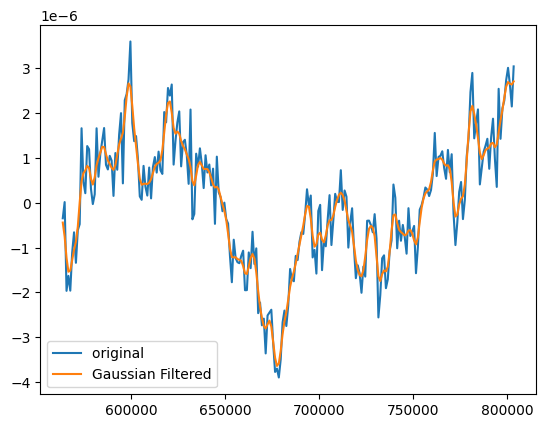

In [37]:
"""slope_array = np.zeros(len(avgY1))
for i in range (len(avgY1)):
    slope_array [i] = slope_calc(avgY1[i], focal = LENSFOCAL)
"""
fit_502, radius_502 = my_fit(myXpos, slope_array, 1)

detrended_slope = (slope_array - fit_502)

filtered_slope = gaussian_filter(detrended_slope, beam_waist = 3)

rms_original = RMS(detrended_slope)
rms_filtered = RMS(filtered_slope)

print(f"Original Fit RMS: {1000000 * rms_original} urad")
print(f"Gaussian smoothed RMS : {1000000 * rms_original} urad")

plt.figure()
plt.plot(myXpos, detrended_slope, label = "original ")
plt.plot(myXpos, filtered_slope, label = "Gaussian Filtered")
plt.legend()
plt.show()


RMS slope from averaging slopes: 1.530443834515419 urad
RMS slope from smoothed averaging slopes: 1.4084548506279821 urad


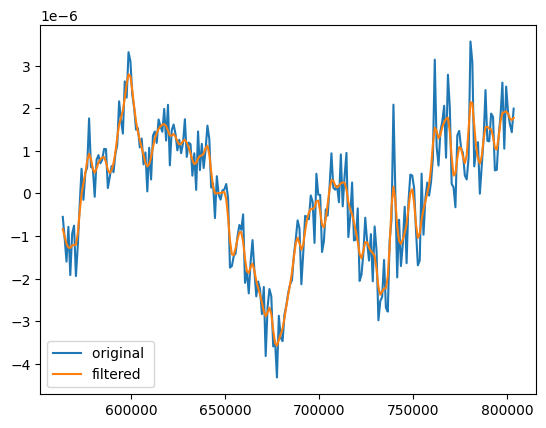

In [26]:
# Detrending from raw slopes, columns 12 and 13 of the data file:

fwd_raw_slope = ltp_data[:,12]
bwd_raw_slope = ltp_data[:,13]

avg_raw_slope = (fwd_raw_slope + bwd_raw_slope) / 2
fit_avg, radius_avg = my_fit(myXpos, avg_raw_slope, 1)

detrended_avg = avg_raw_slope - fit_avg

smoothed_avg = gaussian_filter(detrended_avg, beam_waist = 3)

rms_avg = RMS(detrended_avg)
rms_smooted_avg = RMS(smoothed_avg)
print(f"RMS slope from averaging slopes: {1000000*rms_avg} urad")
print(f"RMS slope from smoothed averaging slopes: {1000000*rms_smooted_avg} urad")

plt.figure()
plt.plot(myXpos, detrended_avg, label = "original ")
plt.plot(myXpos, smoothed_avg, label = "filtered")
plt.legend()
plt.show()